# Dự án Dự đoán độ phổ biến bài hát (Song Popularity Prediction)
Notebook hướng dẫn chi tiết cách lọc dữ liệu nhiễu (outliers), sửa lỗi vẽ biểu đồ phân tán và hoàn thành tính toán huấn luyện mô hình hồi quy.

In [65]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [66]:
# Lọc dữ liệu

# Đọc dữ liệu
df = pd.read_csv("Data Cycling.csv")

# Thay "--" bằng NaN
df.replace("--", np.nan, inplace=True)

# Chuyển activity sang str
df["Activity Type"] = df["Activity Type"].astype("string")

# Các cột số
numeric_columns = [
    "Calories",
    "Avg HR",
    "Max HR",
    "Avg Speed",
    "Max Speed",
    "Elev Gain",
    "Elev Loss",
    "Avg Bike Cadence",
    "Max Bike Cadence",
    "Normalized Power® (NP®)",
    "Max Avg Power (20 min)",
    "Power",
    "Max Power"
]

# Chuyển sang kiểu số
for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

# Điền giá trị thiếu bằng trung bình
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

# Chuẩn hóa cột Time
def fix_time(t):
    t = str(t)

    if t.count(":") == 1:
        t = "00:" + t

    return t

df["Time"] = df["Time"].apply(fix_time)
df["Time"] = pd.to_timedelta(df["Time"], errors="coerce")

# Tạo cột thời gian (phút)
df["Duration(min)"] = df["Time"].dt.total_seconds() / 60
df["Duration(min)"] = df["Duration(min)"].fillna(
    df["Duration(min)"].mean()
)

# Đổi tên cột
df["Activity Type"] = df["Activity Type"].replace("road_biking", "outdoor_cycling")

# Làm tròn số của tất cả các cột
df[numeric_columns] = df[numeric_columns].round(1)
df['Duration(min)'] = df['Duration(min)'].round(1)

# Xóa các cột không dùng
df.drop(columns=["Date", "Time", "Max HR", "Max Speed", "Max Bike Cadence", "Normalized Power® (NP®)", "Max Avg Power (20 min)", "Training Stress Score®", "Power", "Max Power"], inplace=True)

# Xóa dữ liệu trùng
df.drop_duplicates(inplace=True)

# Kiểm tra dữ liệu
print(df.info())
print(df.isnull().sum())

# Xóa outlier
# df = df[
#     (df["Distance"] >= 1) &
#     (df["Distance"] <= 150) &

#     (df["Duration(min)"] >= 5) &
#     (df["Duration(min)"] <= 600) &

#     (df["Avg Speed"] >= 5) &
#     (df["Avg Speed"] <= 60) &

#     (df["Avg HR"] >= 60) &
#     (df["Avg HR"] <= 200) &

#     (df["Avg Bike Cadence"] >= 20) &
#     (df["Avg Bike Cadence"] <= 150) &
    
#     (df["Elev Gain"] <= 2000) &
#     (df["Elev Loss"] <= 2000) 
# ]

df.to_csv("Data Cycling Clean.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Activity Type     340 non-null    string 
 1   Distance          340 non-null    float64
 2   Calories          340 non-null    float64
 3   Avg HR            340 non-null    float64
 4   Avg Speed         340 non-null    float64
 5   Elev Gain         340 non-null    float64
 6   Elev Loss         340 non-null    float64
 7   Avg Bike Cadence  340 non-null    float64
 8   Duration(min)     340 non-null    float64
dtypes: float64(8), string(1)
memory usage: 24.0 KB
None
Activity Type       0
Distance            0
Calories            0
Avg HR              0
Avg Speed           0
Elev Gain           0
Elev Loss           0
Avg Bike Cadence    0
Duration(min)       0
dtype: int64


In [67]:
# Đọc lại dữ liệu đã lọc và làm sạch

df = pd.read_csv("Data Cycling Clean.csv")

df['Activity Type']



0       indoor_cycling
1      outdoor_cycling
2      outdoor_cycling
3       indoor_cycling
4       indoor_cycling
            ...       
335     indoor_cycling
336     indoor_cycling
337     indoor_cycling
338     indoor_cycling
339            cycling
Name: Activity Type, Length: 340, dtype: object

In [68]:
# 3. Tính ma trận nhiệt tương quan
# corr = df_clean.corr(numeric_only=True)
# corr_popularity = corr['popularity'].abs()
# print("--- Tương quan của các biến với cột popularity ---")
# print(corr_popularity.sort_values(ascending=False))

In [69]:
# 4. Chia đặc trưng (X) và biến mục tiêu (y)
X = df[["Distance", "Avg HR", "Avg Speed", "Elev Gain", "Elev Loss", "Avg Bike Cadence", "Duration(min)"]]
y = df["Calories"]


In [70]:
# 5. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Tập Train:", X_train.shape, y_train.shape)
print("Tập Test:", X_test.shape, y_test.shape)

Tập Train: (272, 7) (272,)
Tập Test: (68, 7) (68,)


In [71]:
# 6. Huấn luyện mô hình
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
# 7. Dự đoán và Đánh giá kết quả
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Hệ số xác định R2 Score (Độ chính xác): {r2:.4f}")
print(f"Sai số bình phương trung bình MSE: {mse:.4f}")
print(f"Sai số RMSE: {rmse:.4f}")

joblib.dump({
    "r2": r2,
    "mse": mse,
    "rmse": rmse
}, "metrics.pkl")

Hệ số xác định R2 Score (Độ chính xác): 0.8789
Sai số bình phương trung bình MSE: 15478.4977
Sai số RMSE: 124.4126


['metrics.pkl']

## Vẽ biểu đồ

                  Distance  Duration(min)    Avg HR  Avg Speed  Elev Gain  \
Distance          1.000000      -0.142072  0.207615   0.260873   0.411715   
Duration(min)    -0.142072       1.000000  0.164794   0.098489  -0.083337   
Avg HR            0.207615       0.164794  1.000000   0.083835   0.126508   
Avg Speed         0.260873       0.098489  0.083835   1.000000   0.112173   
Elev Gain         0.411715      -0.083337  0.126508   0.112173   1.000000   
Elev Loss         0.412789      -0.107744  0.125577   0.099378   0.967292   
Avg Bike Cadence  0.280084       0.176103  0.374264   0.342750   0.190313   
Calories          0.962016      -0.151318  0.247706   0.267559   0.443036   

                  Elev Loss  Avg Bike Cadence  Calories  
Distance           0.412789          0.280084  0.962016  
Duration(min)     -0.107744          0.176103 -0.151318  
Avg HR             0.125577          0.374264  0.247706  
Avg Speed          0.099378          0.342750  0.267559  
Elev Gain       

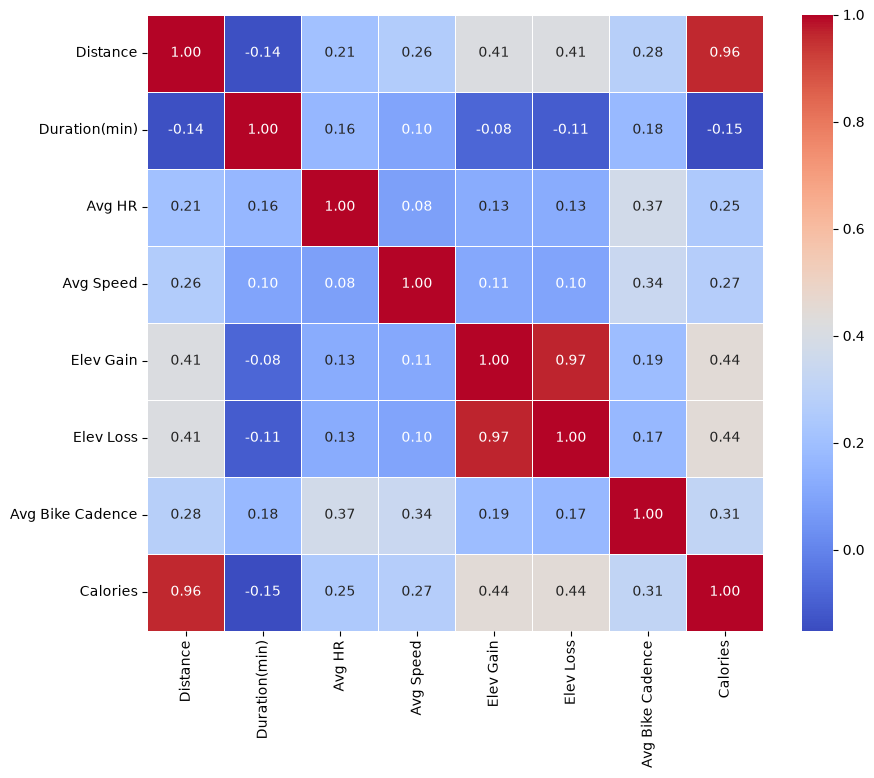

In [73]:
# Heatmap
columns = [
    "Distance",
    "Duration(min)",
    "Avg HR",
    "Avg Speed",
    "Elev Gain",
    "Elev Loss",
    "Avg Bike Cadence",
    "Calories"
]
corr = df[columns].corr()

print(corr)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,          # Hiển thị giá trị
    cmap="coolwarm",     # Màu xanh - đỏ
    fmt=".2f",           # Làm tròn 2 chữ số
    linewidths=0.5,
    square=True
)

plt.savefig("images/heatmap")
plt.show()



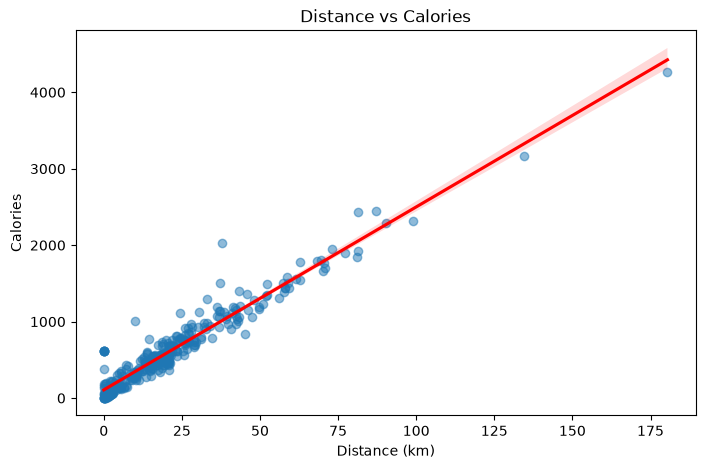

In [74]:
# Distance

df = pd.read_csv("Data Cycling Clean.csv")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Distance",
    y="Calories",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Distance vs Calories")
plt.xlabel("Distance (km)")
plt.ylabel("Calories")

plt.savefig("images/distance")
plt.show()


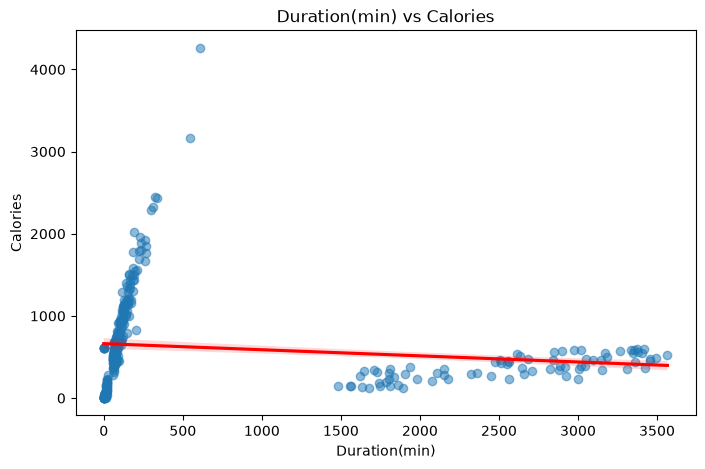

In [75]:
# Duration(min)

df = pd.read_csv("Data Cycling Clean.csv")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Duration(min)",
    y="Calories",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Duration(min) vs Calories")
plt.xlabel("Duration(min)")
plt.ylabel("Calories")
plt.savefig("images/duration(min)")
plt.show()


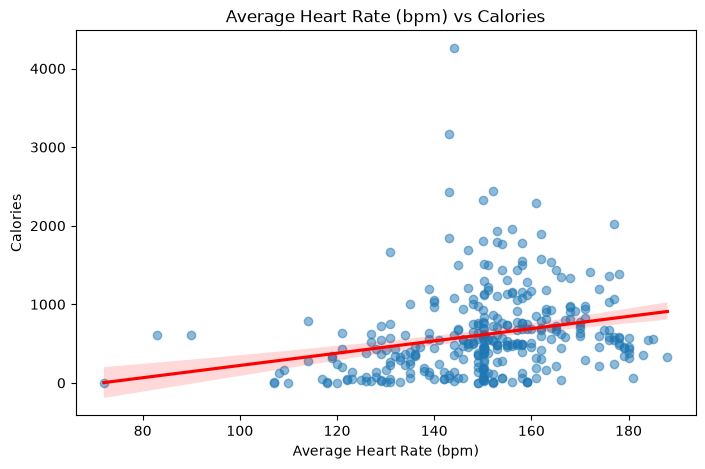

In [76]:
# Avg HR

df = pd.read_csv("Data Cycling Clean.csv")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Avg HR",
    y="Calories",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Average Heart Rate (bpm) vs Calories")
plt.xlabel("Average Heart Rate (bpm)")
plt.ylabel("Calories")
plt.savefig("images/avg_hr")
plt.show()


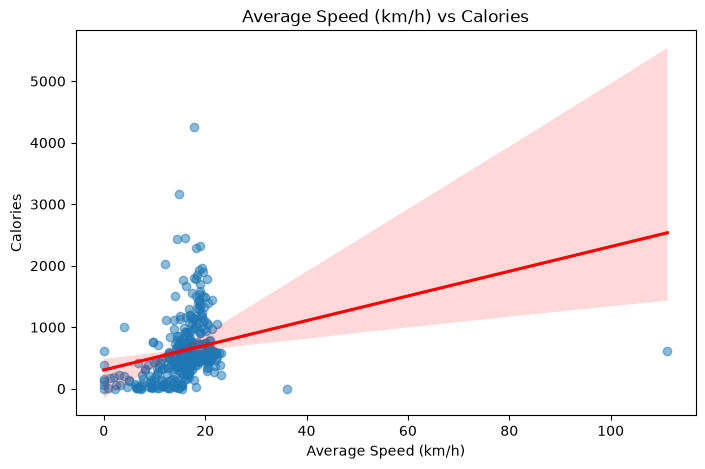

In [77]:
# Avg Speed

df = pd.read_csv("Data Cycling Clean.csv")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Avg Speed",
    y="Calories",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Average Speed (km/h) vs Calories")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Calories")
plt.savefig("images/avg_speed")
plt.show()


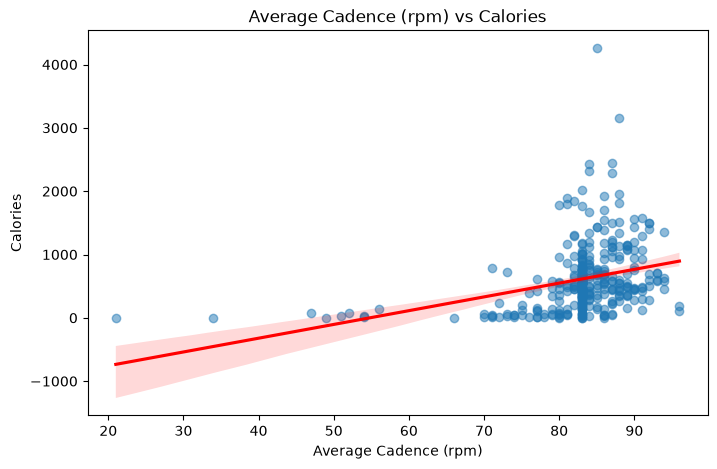

In [78]:
# Avg Bike Cadence

df = pd.read_csv("Data Cycling Clean.csv")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Avg Bike Cadence",
    y="Calories",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Average Cadence (rpm) vs Calories")
plt.xlabel("Average Cadence (rpm)")
plt.ylabel("Calories")
plt.savefig("images/avg_bike_cadence")
plt.show()


## Train indoor và outdoor


In [79]:
# Indoor

indoor_df = df[df["Activity Type"] == "indoor_cycling"]
X = indoor_df[
    [
        "Distance",
        "Duration(min)",
        "Avg HR",
        "Avg Speed",
        "Avg Bike Cadence"
    ]
]

y = indoor_df["Calories"]

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X,y)

joblib.dump(model,"model/indoor_model.pkl")

['model/indoor_model.pkl']

In [80]:
# Outdoor

outdoor_df = df[df["Activity Type"] == "outdoor_cycling"]
X = outdoor_df[
    [
        "Distance",
        "Duration(min)",
        "Avg HR",
        "Avg Speed",
        "Avg Bike Cadence",
        "Elev Gain",
        "Elev Loss"
    ]
]

y = outdoor_df["Calories"]

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X,y)

joblib.dump(model,"model/outdoor_model.pkl")

['model/outdoor_model.pkl']